In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/water_bodies.zip"
extract_path = "/content/drive/MyDrive/Water_Bodies_Dataset"

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Dataset extracted successfully!")
else:
    print("Dataset already extracted.")


Dataset already extracted.


In [3]:
!cp -r /content/drive/MyDrive/Water_Bodies_Dataset /content/


In [4]:
!pip install segmentation-models


In [5]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import Sequence
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import MeanIoU
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate


In [6]:
IMAGE_DIR = "/content/Water_Bodies_Dataset/Water Bodies Dataset/Images"
MASK_DIR  = "/content/Water_Bodies_Dataset/Water Bodies Dataset/Masks"

IMAGE_SIZE = 256


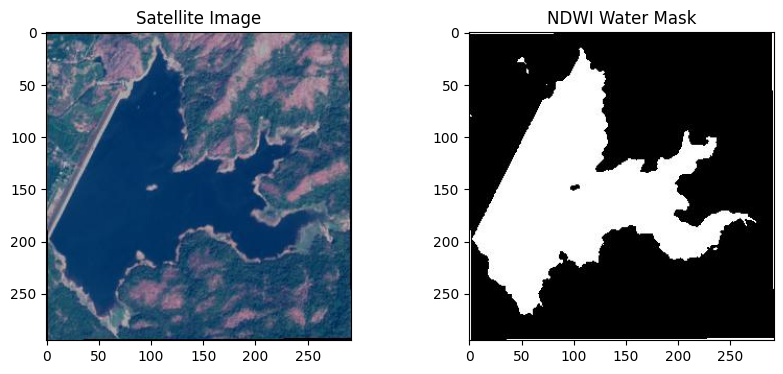

In [7]:
#Read One Sample (Sanity Check)
img_name = os.listdir(IMAGE_DIR)[0]

image = cv2.imread(os.path.join(IMAGE_DIR, img_name))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mask = cv2.imread(os.path.join(MASK_DIR, img_name), cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Satellite Image")

plt.subplot(1,2,2)
plt.imshow(mask, cmap='gray')
plt.title("NDWI Water Mask")
plt.show()


In [8]:
#Data Generator (Memory-Efficient) - Custom Data Generator
class DataGenerator(Sequence):
    def __init__(self, images, batch_size=8):
        self.images = images
        self.batch_size = batch_size

    def __len__(self):
        return len(self.images) // self.batch_size

    def __getitem__(self, idx):
        batch_images = self.images[idx*self.batch_size:(idx+1)*self.batch_size]

        X, y = [], []

        for img_name in batch_images:
            img = cv2.imread(os.path.join(IMAGE_DIR, img_name))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE))
            img = img / 255.0

            mask = cv2.imread(os.path.join(MASK_DIR, img_name), cv2.IMREAD_GRAYSCALE)
            mask = cv2.resize(mask, (IMAGE_SIZE, IMAGE_SIZE))
            mask = mask / 255.0
            mask = np.expand_dims(mask, axis=-1)

            X.append(img)
            y.append(mask)

        return np.array(X), np.array(y)


In [9]:
#Train–Test Split
all_images = os.listdir(IMAGE_DIR)

train_imgs, val_imgs = train_test_split(all_images, test_size=0.2, random_state=42)

train_gen = DataGenerator(train_imgs)
val_gen   = DataGenerator(val_imgs)


In [10]:
#U-Net Model
def build_unet():
    inputs = Input((256,256,3))

    c1 = Conv2D(64, 3, activation='relu', padding='same')(inputs)
    c1 = Conv2D(64, 3, activation='relu', padding='same')(c1)
    p1 = MaxPooling2D()(c1)

    c2 = Conv2D(128, 3, activation='relu', padding='same')(p1)
    c2 = Conv2D(128, 3, activation='relu', padding='same')(c2)
    p2 = MaxPooling2D()(c2)

    c3 = Conv2D(256, 3, activation='relu', padding='same')(p2)
    c3 = Conv2D(256, 3, activation='relu', padding='same')(c3)

    u1 = UpSampling2D()(c3)
    u1 = concatenate([u1, c2])
    c4 = Conv2D(128, 3, activation='relu', padding='same')(u1)

    u2 = UpSampling2D()(c4)
    u2 = concatenate([u2, c1])
    c5 = Conv2D(64, 3, activation='relu', padding='same')(u2)

    outputs = Conv2D(1, 1, activation='sigmoid')(c5)

    return Model(inputs, outputs)


In [42]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import MeanIoU

model = build_unet()
model.compile(
    optimizer=Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', MeanIoU(num_classes=2)]
)


In [43]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# --- Callbacks ---
# Stop training if validation loss doesn't improve for 3 epochs
early_stop = EarlyStopping(
    monitor='val_loss',     # monitor validation loss
    patience=3,             # wait 3 epochs before stopping
    restore_best_weights=True  # restore best model
)

# Optional: save the best model automatically
checkpoint = ModelCheckpoint(
    '/content/drive/MyDrive/MajorProject/unet_water_best.h5',
    monitor='val_loss',
    save_best_only=True
)

# --- Train the model ---
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,           # max epochs, early stopping may stop earlier
    callbacks=[early_stop, checkpoint],
    verbose=1
)




Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.6130 - loss: 0.5523 - mean_io_u_1: 0.3781

282/282 ━━━━━━━━━━━━━━━━━━━━ 128s 340ms/step - accuracy: 0.6131 - loss: 0.5521 - mean_io_u_1: 0.3781 - val_accuracy: 0.6664 - val_loss: 0.4708 - val_mean_io_u_1: 0.3751
Epoch 2/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.6779 - loss: 0.4451 - mean_io_u_1: 0.3771

282/282 ━━━━━━━━━━━━━━━━━━━━ 86s 306ms/step - accuracy: 0.6779 - loss: 0.4451 - mean_io_u_1: 0.3771 - val_accuracy: 0.6593 - val_loss: 0.4674 - val_mean_io_u_1: 0.3751
Epoch 3/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.6923 - loss: 0.4288 - mean_io_u_1: 0.3758

...

282/282 ━━━━━━━━━━━━━━━━━━━━ 82s 290ms/step - accuracy: 0.7255 - loss: 0.3375 - mean_io_u_1: 0.3793 - val_accuracy: 0.7296 - val_loss: 0.3264 - val_mean_io_u_1: 0.3752
Epoch 14/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 85s 301ms/step - accuracy: 0.7342 - loss: 0.3234 - mean_io_u_1: 0.3777 - val_accuracy: 0.7258 - val_loss: 0.3364 - val_mean_io_u_1: 0.3753
Epoch 15/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.7290 - loss: 0.3294 - mean_io_u_1: 0.3815

282/282 ━━━━━━━━━━━━━━━━━━━━ 82s 290ms/step - accuracy: 0.7290 - loss: 0.3293 - mean_io_u_1: 0.3815 - val_accuracy: 0.7299 - val_loss: 0.3239 - val_mean_io_u_1: 0.3755
Epoch 16/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.7303 - loss: 0.3257 - mean_io_u_1: 0.3754

282/282 ━━━━━━━━━━━━━━━━━━━━ 82s 290ms/step - accuracy: 0.7303 - loss: 0.3257 - mean_io_u_1: 0.3754 - val_accuracy: 0.7281 - val_loss: 0.3231 - val_mean_io_u_1: 0.3763
Epoch 17/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.7350 - loss: 0.3172 - mean_io_u_1: 0.3794

282/282 ━━━━━━━━━━━━━━━━━━━━ 82s 290ms/step - accuracy: 0.7350 - loss: 0.3172 - mean_io_u_1: 0.3794 - val_accuracy: 0.7305 - val_loss: 0.3174 - val_mean_io_u_1: 0.3762
Epoch 18/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 81s 286ms/step - accuracy: 0.7342 - loss: 0.3150 - mean_io_u_1: 0.3814 - val_accuracy: 0.7332 - val_loss: 0.3199 - val_mean_io_u_1: 0.3772
Epoch 19/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 81s 286ms/step - accuracy: 0.7444 - loss: 0.2903 - mean_io_u_1: 0.3813 - val_accuracy: 0.7271 - val_loss: 0.3275 - val_mean_io_u_1: 0.3757
Epoch 20/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.7312 - loss: 0.3231 - mean_io_u_1: 0.3782

282/282 ━━━━━━━━━━━━━━━━━━━━ 82s 291ms/step - accuracy: 0.7312 - loss: 0.3231 - mean_io_u_1: 0.3782 - val_accuracy: 0.7353 - val_loss: 0.3090 - val_mean_io_u_1: 0.3766


In [ ]:
model.save('/content/drive/MyDrive/MajorProject/unet_water_model.h5')


In [ ]:
#NDWI Comparison (INNOVATION PART)
#Predict & Compare
def predict_image(img_name):
    img = cv2.imread(os.path.join(IMAGE_DIR, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (256,256))
    img_norm = img / 255.0

    pred = model.predict(np.expand_dims(img_norm, axis=0))[0]
    pred_mask = (pred > 0.5).astype(np.uint8)

    gt_mask = cv2.imread(os.path.join(MASK_DIR, img_name), cv2.IMREAD_GRAYSCALE)
    gt_mask = cv2.resize(gt_mask, (256,256))
    gt_mask = (gt_mask > 127).astype(np.uint8)

    return img, gt_mask, pred_mask

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


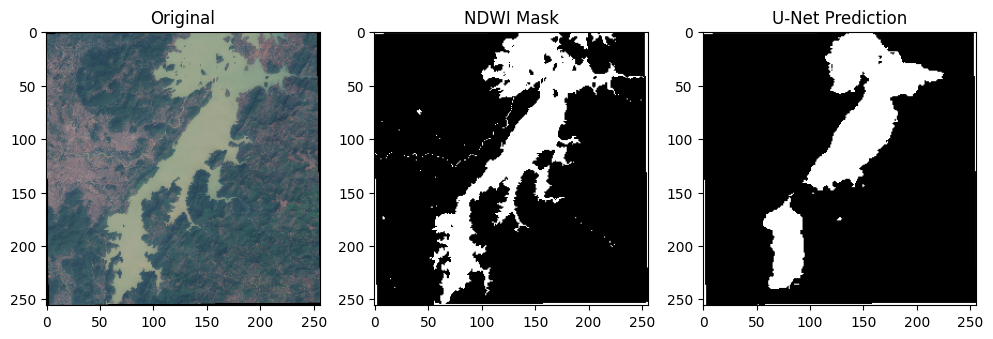

In [ ]:
#Visual Comparison
img, ndwi_mask, unet_mask = predict_image(val_imgs[100])

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(ndwi_mask, cmap='gray')
plt.title("NDWI Mask")

plt.subplot(1,3,3)
plt.imshow(unet_mask, cmap='gray')
plt.title("U-Net Prediction")
plt.show()


In [ ]:
#Water Area Calculation (REAL ANALYSIS)
def calculate_water_area(mask):
    water_pixels = np.sum(mask)
    area_m2 = water_pixels * 100
    area_km2 = area_m2 / 1e6
    return area_km2

area = calculate_water_area(unet_mask)
print(f"Estimated Water Area: {area:.3f} km²")


Estimated Water Area: 1.137 km²


###same with modifications

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Epoch 1/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.5945 - loss: 0.9094 - mean_io_u_1: 0.3759

282/282 ━━━━━━━━━━━━━━━━━━━━ 158s 461ms/step - accuracy: 0.5946 - loss: 0.9091 - mean_io_u_1: 0.3759 - val_accuracy: 0.5312 - val_loss: 1.2140 - val_mean_io_u_1: 0.3723
Epoch 2/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.6390 - loss: 0.7350 - mean_io_u_1: 0.3765

282/282 ━━━━━━━━━━━━━━━━━━━━ 177s 439ms/step - accuracy: 0.6390 - loss: 0.7350 - mean_io_u_1: 0.3765 - val_accuracy: 0.6839 - val_loss: 0.8162 - val_mean_io_u_1: 0.3723
Epoch 3/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.6523 - loss: 0.6813 - mean_io_u_1: 0.3765

282/282 ━━━━━━━━━━━━━━━━━━━━ 124s 439ms/step - accuracy: 0.6523 - loss: 0.6813 - mean_io_u_1: 0.3765 - val_accuracy: 0.7237 - val_loss: 0.6625 - val_mean_io_u_1: 0.3723
Epoch 4/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.6585 - loss: 0.6541 - mean_io_u_1: 0.3750

282/282 ━━━━━━━━━━━━━━━━━━━━ 125s 443ms/step - accuracy: 0.6584 - loss: 0.6541 - mean_io_u_1: 0.3750 - val_accuracy: 0.7244 - val_loss: 0.6502 - val_mean_io_u_1: 0.3754
Epoch 5/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.6638 - loss: 0.6265 - mean_io_u_1: 0.3789

...

282/282 ━━━━━━━━━━━━━━━━━━━━ 124s 440ms/step - accuracy: 0.6870 - loss: 0.5136 - mean_io_u_1: 0.3855 - val_accuracy: 0.7445 - val_loss: 0.5583 - val_mean_io_u_1: 0.3778
Epoch 18/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 123s 435ms/step - accuracy: 0.6830 - loss: 0.5290 - mean_io_u_1: 0.3794 - val_accuracy: 0.7451 - val_loss: 0.5595 - val_mean_io_u_1: 0.3865
Epoch 19/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.6901 - loss: 0.5047 - mean_io_u_1: 0.3816

282/282 ━━━━━━━━━━━━━━━━━━━━ 124s 440ms/step - accuracy: 0.6901 - loss: 0.5048 - mean_io_u_1: 0.3816 - val_accuracy: 0.7497 - val_loss: 0.5436 - val_mean_io_u_1: 0.3910
Epoch 20/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.6878 - loss: 0.4970 - mean_io_u_1: 0.3896

282/282 ━━━━━━━━━━━━━━━━━━━━ 128s 452ms/step - accuracy: 0.6879 - loss: 0.4970 - mean_io_u_1: 0.3896 - val_accuracy: 0.7497 - val_loss: 0.5357 - val_mean_io_u_1: 0.3801
Epoch 21/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.6902 - loss: 0.4902 - mean_io_u_1: 0.3821

282/282 ━━━━━━━━━━━━━━━━━━━━ 124s 439ms/step - accuracy: 0.6902 - loss: 0.4902 - mean_io_u_1: 0.3821 - val_accuracy: 0.7499 - val_loss: 0.5327 - val_mean_io_u_1: 0.3884
Epoch 22/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.6928 - loss: 0.4797 - mean_io_u_1: 0.3881

282/282 ━━━━━━━━━━━━━━━━━━━━ 124s 439ms/step - accuracy: 0.6928 - loss: 0.4798 - mean_io_u_1: 0.3881 - val_accuracy: 0.7541 - val_loss: 0.5258 - val_mean_io_u_1: 0.3814
Epoch 23/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 124s 437ms/step - accuracy: 0.6901 - loss: 0.4968 - mean_io_u_1: 0.3856 - val_accuracy: 0.7517 - val_loss: 0.5271 - val_mean_io_u_1: 0.3926
Epoch 24/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 122s 433ms/step - accuracy: 0.6950 - loss: 0.4728 - mean_io_u_1: 0.3895 - val_accuracy: 0.7114 - val_loss: 0.6547 - val_mean_io_u_1: 0.3851
Epoch 25/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 122s 433ms/step - accuracy: 0.6955 - loss: 0.4723 - mean_io_u_1: 0.3921 - val_accuracy: 0.7508 - val_loss: 0.5470 - val_mean_io_u_1: 0.3763
Epoch 26/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 122s 433ms/step - accuracy: 0.7002 - loss: 0.4718 - mean_io_u_1: 0.3898 - val_accuracy: 0.7401 - val_loss: 0.5641 - val_mean_io_u_1: 0.3830
Epoch 27/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 142s 433ms/step - accuracy: 0.6904 - loss: 0.4677 - mean_io_u_1: 0

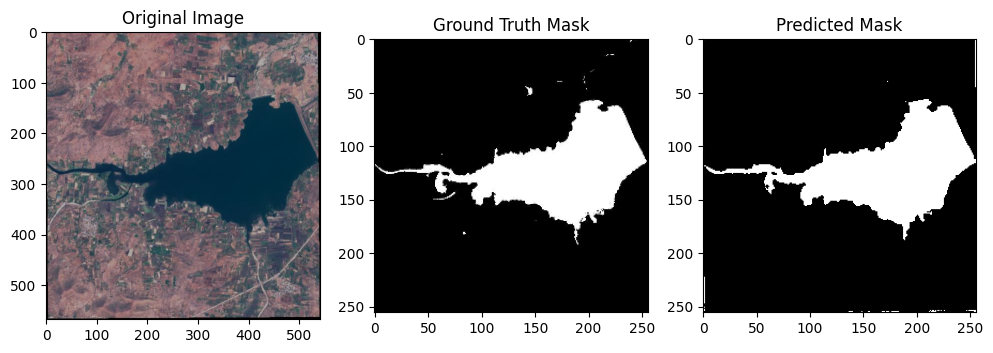

Predicted Water Area: 1112700 sq.m
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


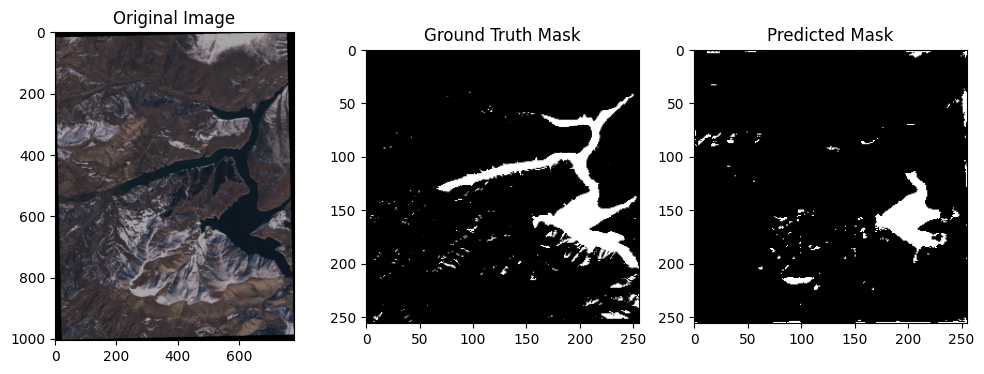

Predicted Water Area: 335200 sq.m
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


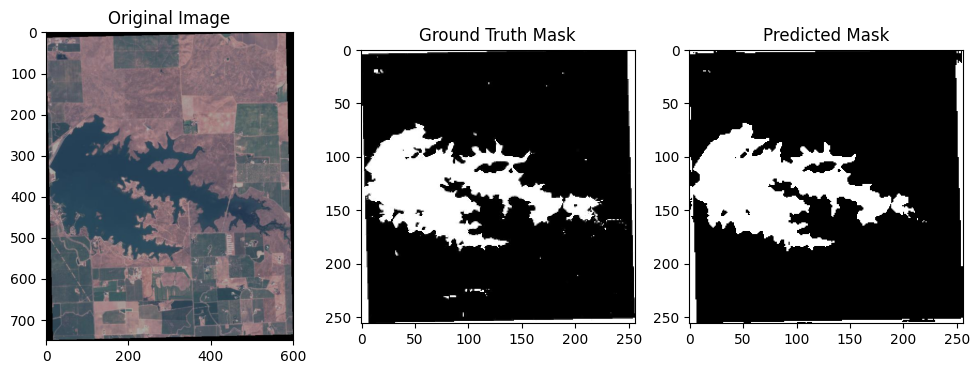

Predicted Water Area: 1310000 sq.m


In [ ]:
# ==============================
# 1️⃣ Mount Google Drive
# ==============================
from google.colab import drive
drive.mount('/content/drive')

# ==============================
# 2️⃣ Imports
# ==============================
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from glob import glob
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import MeanIoU
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import Sequence
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ==============================
# 3️⃣ Dataset Paths
# ==============================
IMAGE_DIR = "/content/Water_Bodies_Dataset/Water Bodies Dataset/Images"
MASK_DIR  = "/content/Water_Bodies_Dataset/Water Bodies Dataset/Masks"

IMAGE_SIZE = 256  # Resize images

# ==============================
# 4️⃣ Custom Data Generator with Augmentation
# ==============================
class DataGenerator(Sequence):
    def __init__(self, images, batch_size=8, augment=False):
        self.images = images
        self.batch_size = batch_size
        self.augment = augment
        self.img_datagen = ImageDataGenerator(
            rotation_range=20,
            width_shift_range=0.1,
            height_shift_range=0.1,
            horizontal_flip=True,
            vertical_flip=True,
            zoom_range=0.1
        )
        self.mask_datagen = ImageDataGenerator(
            rotation_range=20,
            width_shift_range=0.1,
            height_shift_range=0.1,
            horizontal_flip=True,
            vertical_flip=True,
            zoom_range=0.1
        )

    def __len__(self):
        return len(self.images) // self.batch_size

    def __getitem__(self, idx):
        batch_images = self.images[idx*self.batch_size:(idx+1)*self.batch_size]
        X, y = [], []
        for img_name in batch_images:
            # Read and preprocess image
            img = cv2.imread(os.path.join(IMAGE_DIR, img_name))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE))
            img = img / 255.0

            # Read and preprocess mask
            mask = cv2.imread(os.path.join(MASK_DIR, img_name), cv2.IMREAD_GRAYSCALE)
            mask = cv2.resize(mask, (IMAGE_SIZE, IMAGE_SIZE))
            mask = mask / 255.0
            mask = np.expand_dims(mask, axis=-1)

            X.append(img)
            y.append(mask)

        X = np.array(X)
        y = np.array(y)

        # Apply augmentation
        if self.augment:
            seed = np.random.randint(1e6)
            X = iter(self.img_datagen.flow(X, batch_size=self.batch_size, shuffle=False, seed=seed)).__next__()
            y = iter(self.mask_datagen.flow(y, batch_size=self.batch_size, shuffle=False, seed=seed)).__next__()

        return X, y

# ==============================
# 5️⃣ Train-Test Split
# ==============================
all_images = sorted(os.listdir(IMAGE_DIR))
train_imgs, val_imgs = train_test_split(all_images, test_size=0.2, random_state=42)

train_gen = DataGenerator(train_imgs, batch_size=8, augment=True)
val_gen   = DataGenerator(val_imgs, batch_size=8, augment=False)

# ==============================
# 6️⃣ Improved U-Net Model (with BatchNorm & more filters)
# ==============================
def build_unet():
    inputs = Input((IMAGE_SIZE, IMAGE_SIZE, 3))

    # Encoder
    c1 = Conv2D(64, 3, activation='relu', padding='same')(inputs)
    c1 = BatchNormalization()(c1)
    c1 = Conv2D(64, 3, activation='relu', padding='same')(c1)
    c1 = BatchNormalization()(c1)
    p1 = MaxPooling2D()(c1)

    c2 = Conv2D(128, 3, activation='relu', padding='same')(p1)
    c2 = BatchNormalization()(c2)
    c2 = Conv2D(128, 3, activation='relu', padding='same')(c2)
    c2 = BatchNormalization()(c2)
    p2 = MaxPooling2D()(c2)

    c3 = Conv2D(256, 3, activation='relu', padding='same')(p2)
    c3 = BatchNormalization()(c3)
    c3 = Conv2D(256, 3, activation='relu', padding='same')(c3)
    c3 = BatchNormalization()(c3)
    p3 = MaxPooling2D()(c3)

    c4 = Conv2D(512, 3, activation='relu', padding='same')(p3)
    c4 = BatchNormalization()(c4)
    c4 = Conv2D(512, 3, activation='relu', padding='same')(c4)
    c4 = BatchNormalization()(c4)

    # Decoder
    u1 = UpSampling2D()(c4)
    u1 = concatenate([u1, c3])
    c5 = Conv2D(256, 3, activation='relu', padding='same')(u1)
    c5 = BatchNormalization()(c5)
    c5 = Conv2D(256, 3, activation='relu', padding='same')(c5)
    c5 = BatchNormalization()(c5)

    u2 = UpSampling2D()(c5)
    u2 = concatenate([u2, c2])
    c6 = Conv2D(128, 3, activation='relu', padding='same')(u2)
    c6 = BatchNormalization()(c6)
    c6 = Conv2D(128, 3, activation='relu', padding='same')(c6)
    c6 = BatchNormalization()(c6)

    u3 = UpSampling2D()(c6)
    u3 = concatenate([u3, c1])
    c7 = Conv2D(64, 3, activation='relu', padding='same')(u3)
    c7 = BatchNormalization()(c7)
    c7 = Conv2D(64, 3, activation='relu', padding='same')(c7)
    c7 = BatchNormalization()(c7)

    outputs = Conv2D(1, 1, activation='sigmoid')(c7)
    return Model(inputs, outputs)

# ==============================
# 7️⃣ Dice + BCE Loss
# ==============================
def dice_loss(y_true, y_pred, smooth=1):
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

# ==============================
# 8️⃣ Compile Model
# ==============================
model = build_unet()
model.compile(
    optimizer=Adam(1e-4),
    loss=bce_dice_loss,
    metrics=['accuracy', MeanIoU(num_classes=2)]
)

# ==============================
# 9️⃣ Callbacks
# ==============================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    '/content/drive/MyDrive/MajorProject/unet_water_best.h5',
    monitor='val_loss',
    save_best_only=True
)

# ==============================
#  🔟 Train Model
# ==============================
steps_per_epoch = len(train_imgs) // 8
validation_steps = len(val_imgs) // 8

history = model.fit(
    train_gen,
    validation_data=val_gen,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    epochs=30,
    callbacks=[early_stop, checkpoint]
)

# ==============================
#  1️⃣1️⃣ Load Best Model & Evaluate
# ==============================
model = load_model('/content/drive/MyDrive/MajorProject/unet_water_best.h5',
                   compile=False)
model.compile(optimizer=Adam(1e-4), loss=bce_dice_loss, metrics=['accuracy', MeanIoU(num_classes=2)])

results = model.evaluate(val_gen, steps=validation_steps)
print("Validation results:", results)

# ==============================
#  1️⃣2️⃣ Predict & Visualize
# ==============================
def display_prediction(idx):
    img_name = val_imgs[idx]
    img = cv2.imread(os.path.join(IMAGE_DIR, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE))
    img_input = img_resized / 255.0

    mask = cv2.imread(os.path.join(MASK_DIR, img_name), cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (IMAGE_SIZE, IMAGE_SIZE))

    pred_mask = model.predict(np.expand_dims(img_input, axis=0))[0,:,:,0]
    pred_mask_bin = (pred_mask > 0.5).astype(np.uint8)

    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.subplot(1,3,2)
    plt.imshow(mask, cmap='gray')
    plt.title("Ground Truth Mask")
    plt.subplot(1,3,3)
    plt.imshow(pred_mask_bin, cmap='gray')
    plt.title("Predicted Mask")
    plt.show()

    # Water area in sq. meters (Sentinel-2: 10m per pixel)
    water_pixels = np.sum(pred_mask_bin)
    water_area = water_pixels * 10 * 10
    print(f"Predicted Water Area: {water_area} sq.m")

# Example: visualize first 3 images
for i in range(3):
    display_prediction(i)


Wed Mar  4 10:07:09 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   73C    P0             30W /   70W |   13881MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_54 (Conv2D)  │ (None, 256, 256,  │      1,792 │ input_layer_5[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_55 (Conv2D)  │ (None, 256, 256,  │     36,928 │ conv2d_54[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 128, 128,  │          0 │ conv2d_55[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_56 (Conv2D)  │ (None, 128, 128,  │     73,856 │ max_pooling2d_9[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_57 (Conv2D)  │ (None, 128, 128,  │    147,584 │ conv2d_56[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 64, 64,    │          0 │ conv2d_57[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_58 (Conv2D)  │ (None, 64, 64,    │    295,168 │ max_pooling2d_10… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_59 (Conv2D)  │ (None, 64, 64,    │    590,080 │ conv2d_58[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_11    │ (None, 32, 32,    │          0 │ conv2d_59[0][0]   │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_60 (Conv2D)  │ (None, 32, 32,    │  1,180,160 │ max_pooling2d_11… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_61 (Conv2D)  │ (None, 32, 32,    │  2,359,808 │ conv2d_60[0][0]   │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_12    │ (None, 16, 16,    │          0 │ conv2d_61[0][0]   │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_62 (Conv2D)  │ (None, 16, 16,    │  4,719,616 │ max_pooling2d_12… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_63 (Conv2D)  │ (None, 16, 16,    │  9,438,208 │ conv2d_62[0][0]   │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_18    │ (None, 32, 32,    │          0 │ conv2d_63[0][0]   │
│ (UpSampling2D)      │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_17      │ (None, 32, 32,    │          0 │ up_sampling2d_18

 Total params: 31,378,945 (119.70 MB)

 Trainable params: 31,378,945 (119.70 MB)

...

282/282 ━━━━━━━━━━━━━━━━━━━━ 66s 233ms/step - accuracy: 0.8242 - dice_coef: 0.7904 - iou_metric: 0.7255 - loss: 0.4877 - val_accuracy: 0.8226 - val_dice_coef: 0.7886 - val_iou_metric: 0.7189 - val_loss: 0.5026 - learning_rate: 5.0000e-05
Epoch 12/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.8231 - dice_coef: 0.7963 - iou_metric: 0.7293 - loss: 0.4755

282/282 ━━━━━━━━━━━━━━━━━━━━ 62s 220ms/step - accuracy: 0.8231 - dice_coef: 0.7963 - iou_metric: 0.7294 - loss: 0.4754 - val_accuracy: 0.8258 - val_dice_coef: 0.8030 - val_iou_metric: 0.7259 - val_loss: 0.4858 - learning_rate: 5.0000e-05
Epoch 13/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.8245 - dice_coef: 0.8050 - iou_metric: 0.7374 - loss: 0.4593

282/282 ━━━━━━━━━━━━━━━━━━━━ 85s 233ms/step - accuracy: 0.8246 - dice_coef: 0.8050 - iou_metric: 0.7374 - loss: 0.4593 - val_accuracy: 0.8292 - val_dice_coef: 0.8003 - val_iou_metric: 0.7326 - val_loss: 0.4690 - learning_rate: 5.0000e-05
Epoch 14/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 50s 178ms/step - accuracy: 0.8289 - dice_coef: 0.8083 - iou_metric: 0.7431 - loss: 0.4536 - val_accuracy: 0.8259 - val_dice_coef: 0.7958 - val_iou_metric: 0.7269 - val_loss: 0.4829 - learning_rate: 5.0000e-05
Epoch 15/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 47s 166ms/step - accuracy: 0.8264 - dice_coef: 0.8128 - iou_metric: 0.7476 - loss: 0.4396 - val_accuracy: 0.8272 - val_dice_coef: 0.8003 - val_iou_metric: 0.7269 - val_loss: 0.4730 - learning_rate: 5.0000e-05
Epoch 16/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.8290 - dice_coef: 0.8148 - iou_metric: 0.7494 - loss: 0.4420

282/282 ━━━━━━━━━━━━━━━━━━━━ 65s 229ms/step - accuracy: 0.8290 - dice_coef: 0.8148 - iou_metric: 0.7494 - loss: 0.4420 - val_accuracy: 0.8312 - val_dice_coef: 0.8192 - val_iou_metric: 0.7411 - val_loss: 0.4601 - learning_rate: 5.0000e-05
Epoch 17/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 49s 174ms/step - accuracy: 0.8358 - dice_coef: 0.8224 - iou_metric: 0.7596 - loss: 0.4213 - val_accuracy: 0.8231 - val_dice_coef: 0.7920 - val_iou_metric: 0.7332 - val_loss: 0.4794 - learning_rate: 5.0000e-05
Epoch 18/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 48s 168ms/step - accuracy: 0.8346 - dice_coef: 0.8251 - iou_metric: 0.7666 - loss: 0.4133 - val_accuracy: 0.8269 - val_dice_coef: 0.7816 - val_iou_metric: 0.7286 - val_loss: 0.4843 - learning_rate: 5.0000e-05
Epoch 19/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 48s 169ms/step - accuracy: 0.8324 - dice_coef: 0.8259 - iou_metric: 0.7649 - loss: 0.4141 - val_accuracy: 0.8305 - val_dice_coef: 0.8048 - val_iou_metric: 0.7308 - val_loss: 0.4739 - learning_rate: 5.0000e-05
Epoch 20/30


282/282 ━━━━━━━━━━━━━━━━━━━━ 59s 210ms/step - accuracy: 0.8389 - dice_coef: 0.8372 - iou_metric: 0.7770 - loss: 0.3889 - val_accuracy: 0.8344 - val_dice_coef: 0.8201 - val_iou_metric: 0.7498 - val_loss: 0.4418 - learning_rate: 2.5000e-05
Epoch 21/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 50s 178ms/step - accuracy: 0.8376 - dice_coef: 0.8328 - iou_metric: 0.7709 - loss: 0.3949 - val_accuracy: 0.8323 - val_dice_coef: 0.8170 - val_iou_metric: 0.7369 - val_loss: 0.4617 - learning_rate: 2.5000e-05
Epoch 22/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 47s 167ms/step - accuracy: 0.8463 - dice_coef: 0.8495 - iou_metric: 0.7922 - loss: 0.3632 - val_accuracy: 0.8326 - val_dice_coef: 0.8258 - val_iou_metric: 0.7491 - val_loss: 0.4484 - learning_rate: 2.5000e-05
Epoch 23/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 49s 172ms/step - accuracy: 0.8455 - dice_coef: 0.8471 - iou_metric: 0.7899 - loss: 0.3672 - val_accuracy: 0.8344 - val_dice_coef: 0.8241 - val_iou_metric: 0.7507 - val_loss: 0.4447 - learning_rate: 2.5000e-05
Epoch 24/30


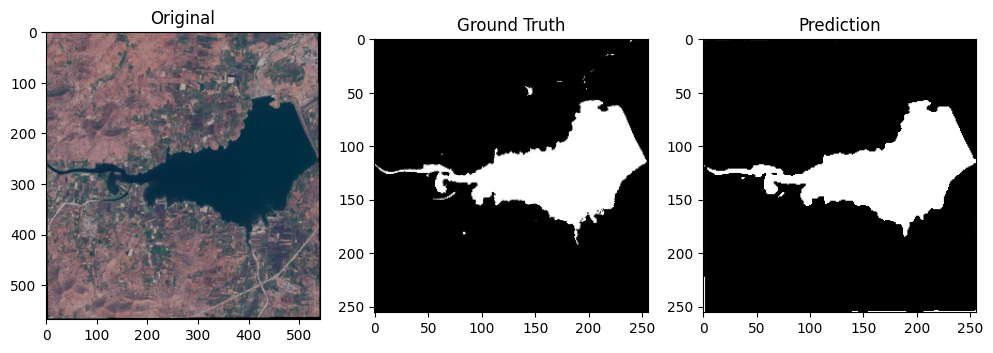

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


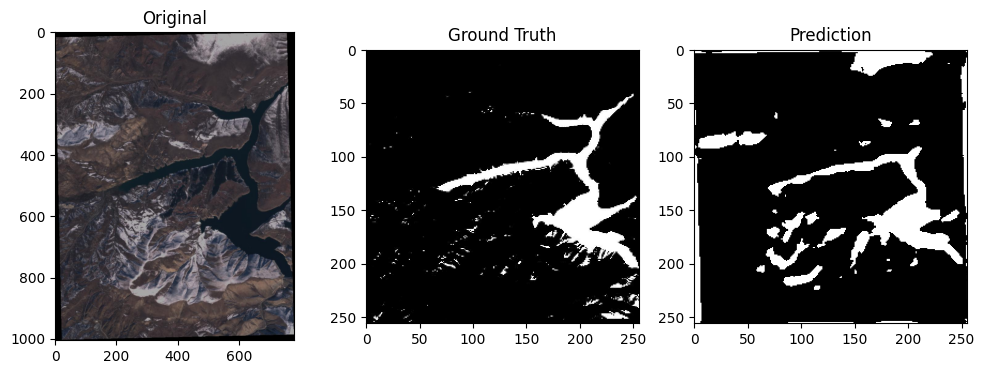

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


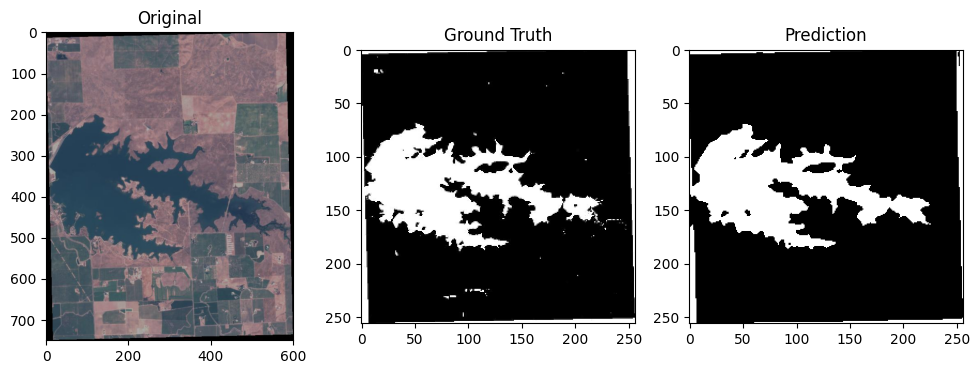

In [ ]:
# ============================================================
# 🌊 WATER BODY DETECTION - ERROR FREE VERSION
# ============================================================

# ================= GPU CHECK =================
!nvidia-smi

# ================= IMPORTS =================
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from google.colab import drive

# ================= MOUNT DRIVE =================
drive.mount('/content/drive')

# ================= PATHS =================
IMAGE_DIR = "/content/Water_Bodies_Dataset/Water Bodies Dataset/Images"
MASK_DIR  = "/content/Water_Bodies_Dataset/Water Bodies Dataset/Masks"

IMAGE_SIZE = 256
BATCH_SIZE = 8

# ================= LOAD FILE NAMES =================
all_images = sorted(os.listdir(IMAGE_DIR))
train_imgs, val_imgs = train_test_split(all_images, test_size=0.2, random_state=42)

# ================= DATA GENERATOR =================
class DataGenerator(tf.keras.utils.Sequence):
    def __init__(self, image_list, batch_size=8, augment=False):
        self.image_list = image_list
        self.batch_size = batch_size
        self.augment = augment

    def __len__(self):
        return len(self.image_list) // self.batch_size

    def __getitem__(self, idx):
        batch = self.image_list[idx*self.batch_size:(idx+1)*self.batch_size]
        X, y = [], []

        for name in batch:
            img = cv2.imread(os.path.join(IMAGE_DIR, name))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE))
            img = img / 255.0

            mask = cv2.imread(os.path.join(MASK_DIR, name), 0)
            mask = cv2.resize(mask, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_NEAREST)
            mask = mask / 255.0
            mask = np.expand_dims(mask, axis=-1)

            if self.augment:
                if np.random.rand() > 0.5:
                    img = np.fliplr(img)
                    mask = np.fliplr(mask)

            X.append(img)
            y.append(mask)

        return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

train_gen = DataGenerator(train_imgs, BATCH_SIZE, augment=True)
val_gen   = DataGenerator(val_imgs, BATCH_SIZE, augment=False)

# ================= U-NET MODEL =================
def build_unet():
    inputs = layers.Input((IMAGE_SIZE, IMAGE_SIZE, 3))

    # Encoder
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D()(c2)

    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D()(c3)

    c4 = layers.Conv2D(512, 3, activation='relu', padding='same')(p3)
    c4 = layers.Conv2D(512, 3, activation='relu', padding='same')(c4)
    p4 = layers.MaxPooling2D()(c4)

    # Bridge
    b1 = layers.Conv2D(1024, 3, activation='relu', padding='same')(p4)
    b1 = layers.Conv2D(1024, 3, activation='relu', padding='same')(b1)

    # Decoder
    u1 = layers.UpSampling2D()(b1)
    u1 = layers.concatenate([u1, c4])
    c5 = layers.Conv2D(512, 3, activation='relu', padding='same')(u1)
    c5 = layers.Conv2D(512, 3, activation='relu', padding='same')(c5)

    u2 = layers.UpSampling2D()(c5)
    u2 = layers.concatenate([u2, c3])
    c6 = layers.Conv2D(256, 3, activation='relu', padding='same')(u2)
    c6 = layers.Conv2D(256, 3, activation='relu', padding='same')(c6)

    u3 = layers.UpSampling2D()(c6)
    u3 = layers.concatenate([u3, c2])
    c7 = layers.Conv2D(128, 3, activation='relu', padding='same')(u3)
    c7 = layers.Conv2D(128, 3, activation='relu', padding='same')(c7)

    u4 = layers.UpSampling2D()(c7)
    u4 = layers.concatenate([u4, c1])
    c8 = layers.Conv2D(64, 3, activation='relu', padding='same')(u4)
    c8 = layers.Conv2D(64, 3, activation='relu', padding='same')(c8)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c8)

    return models.Model(inputs, outputs)

model = build_unet()
model.summary()


# ================= METRICS (FIXED FOR FLOAT16 ISSUE) =================
def dice_coef(y_true, y_pred, smooth=1):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )

def total_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + (1 - dice_coef(y_true, y_pred))

def iou_metric(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred > 0.5, tf.float32)

    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
    return intersection / (union + 1e-7)

# ================= COMPILE =================
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=total_loss,
    metrics=['accuracy', dice_coef, iou_metric]
)

# ================= CALLBACKS =================
callbacks = [
    EarlyStopping(patience=6, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.5),
    ModelCheckpoint('/content/drive/MyDrive/water_best.h5', save_best_only=True)
]

# ================= TRAIN =================
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=callbacks
)

# ================= VISUALIZE =================
def show_prediction(idx):
    name = val_imgs[idx]
    img = cv2.imread(os.path.join(IMAGE_DIR, name))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (IMAGE_SIZE, IMAGE_SIZE)) / 255.0

    mask = cv2.imread(os.path.join(MASK_DIR, name), 0)
    mask_resized = cv2.resize(mask, (IMAGE_SIZE, IMAGE_SIZE))

    pred = model.predict(np.expand_dims(img_resized, 0))[0,:,:,0]
    pred_bin = (pred > 0.5).astype(np.uint8)

    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1)
    plt.imshow(img_rgb)
    plt.title("Original")

    plt.subplot(1,3,2)
    plt.imshow(mask_resized, cmap='gray')
    plt.title("Ground Truth")

    plt.subplot(1,3,3)
    plt.imshow(pred_bin, cmap='gray')
    plt.title("Prediction")
    plt.show()

for i in range(3):
    show_prediction(i)

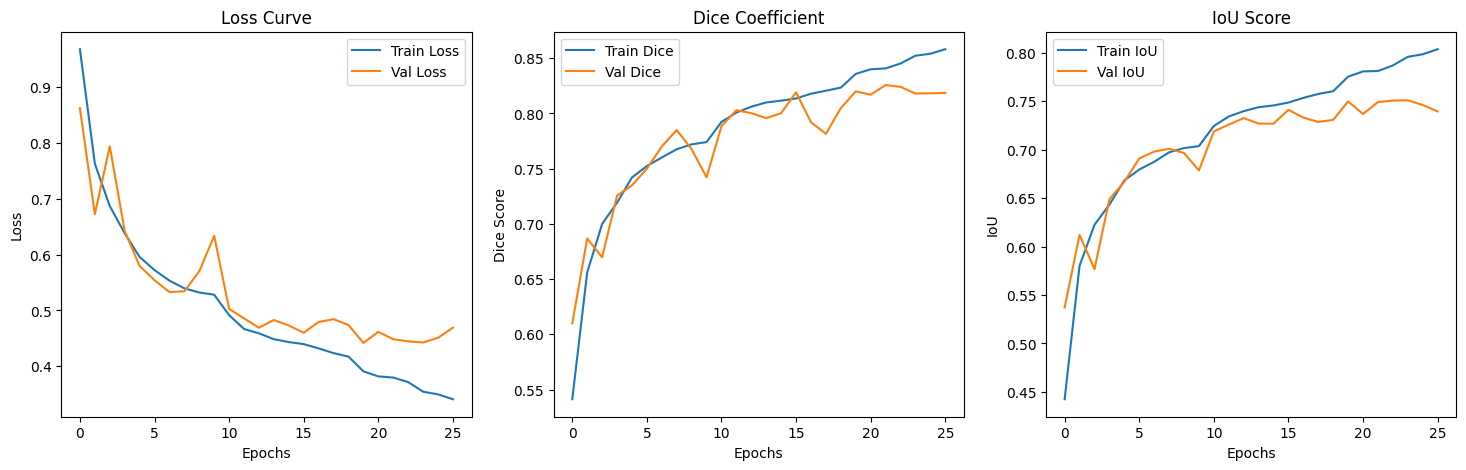

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


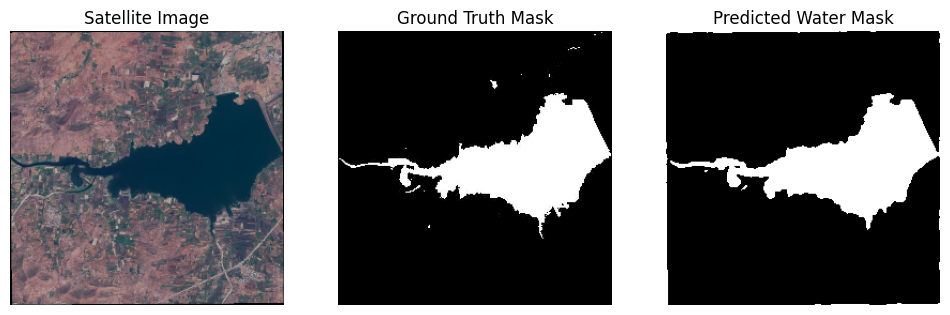

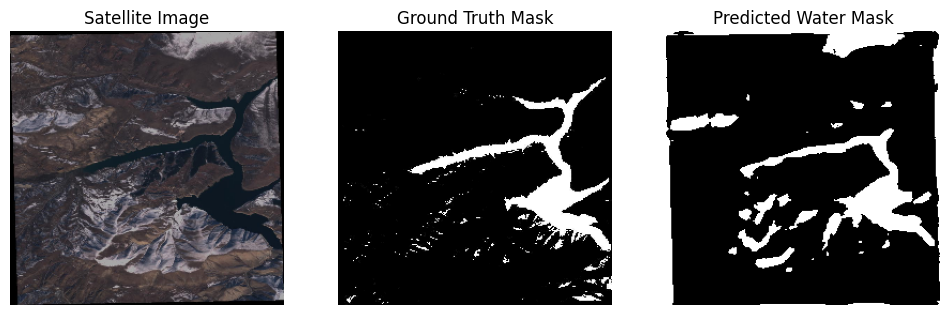

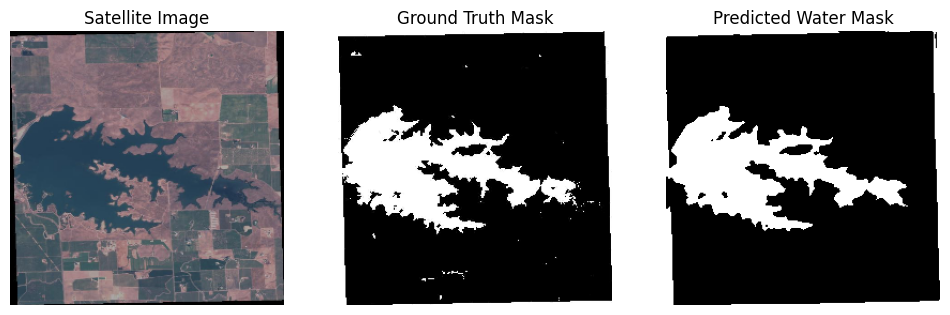

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# ================= TRAINING CURVES =================

plt.figure(figsize=(18,5))

# Loss
plt.subplot(1,3,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# Dice Coefficient
plt.subplot(1,3,2)
plt.plot(history.history['dice_coef'], label='Train Dice')
plt.plot(history.history['val_dice_coef'], label='Val Dice')
plt.title("Dice Coefficient")
plt.xlabel("Epochs")
plt.ylabel("Dice Score")
plt.legend()

# IoU
plt.subplot(1,3,3)
plt.plot(history.history['iou_metric'], label='Train IoU')
plt.plot(history.history['val_iou_metric'], label='Val IoU')
plt.title("IoU Score")
plt.xlabel("Epochs")
plt.ylabel("IoU")
plt.legend()

plt.show()


# ================= FIXED SAMPLE PREDICTIONS =================

def show_predictions(model, generator, num=3):

    # Get first batch using indexing (NOT next())
    images, masks = generator[0]

    preds = model.predict(images)

    for i in range(min(num, len(images))):
        plt.figure(figsize=(12,4))

        # Original Image
        plt.subplot(1,3,1)
        plt.imshow(images[i])
        plt.title("Satellite Image")
        plt.axis("off")

        # Ground Truth
        plt.subplot(1,3,2)
        plt.imshow(masks[i].squeeze(), cmap='gray')
        plt.title("Ground Truth Mask")
        plt.axis("off")

        # Prediction
        plt.subplot(1,3,3)
        plt.imshow((preds[i].squeeze() > 0.5), cmap='gray')
        plt.title("Predicted Water Mask")
        plt.axis("off")

        plt.show()


# Call function
show_predictions(model, val_gen, num=3)

In [ ]:
print("===== FINAL TRAINING METRICS =====")
print(f"Final Training Loss: {history.history['loss'][-1]:.4f}")
print(f"Final Training Dice Coefficient: {history.history['dice_coef'][-1]:.4f}")
print(f"Final Training IoU: {history.history['iou_metric'][-1]:.4f}")

print("\n===== FINAL VALIDATION METRICS =====")
print(f"Final Validation Loss: {history.history['val_loss'][-1]:.4f}")
print(f"Final Validation Dice Coefficient: {history.history['val_dice_coef'][-1]:.4f}")
print(f"Final Validation IoU: {history.history['val_iou_metric'][-1]:.4f}")

===== FINAL TRAINING METRICS =====
Final Training Loss: 0.3411
Final Training Dice Coefficient: 0.8582
Final Training IoU: 0.8037

===== FINAL VALIDATION METRICS =====
Final Validation Loss: 0.4692
Final Validation Dice Coefficient: 0.8186
Final Validation IoU: 0.7395


In [ ]:
print("\n===== DETAILED METRIC EVALUATION =====")

results = model.evaluate(val_gen, return_dict=True)

for key, value in results.items():
    print(f"{key}: {value:.4f}")


===== DETAILED METRIC EVALUATION =====
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - accuracy: 0.8374 - dice_coef: 0.8182 - iou_metric: 0.7498 - loss: 0.4454
accuracy: 0.8344
dice_coef: 0.8201
iou_metric: 0.7498
loss: 0.4418


In [ ]:
model.save("water_body_models.h5")
print("Model saved as H5 file!")

Model saved as H5 file!


In [12]:
from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/water_best.h5', compile=False)

In [13]:
predictions = model.predict(val_gen)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


70/70 ━━━━━━━━━━━━━━━━━━━━ 20s 83ms/step


In [15]:
#Convert to masks
pred_masks = (predictions > 0.5).astype(np.uint8)

In [17]:
#caluculating water percentage
percentages = []

for mask in pred_masks:
    water_pixels = np.sum(mask)
    total_pixels = mask.size
    percentage = (water_pixels / total_pixels) * 100
    percentages.append(percentage)

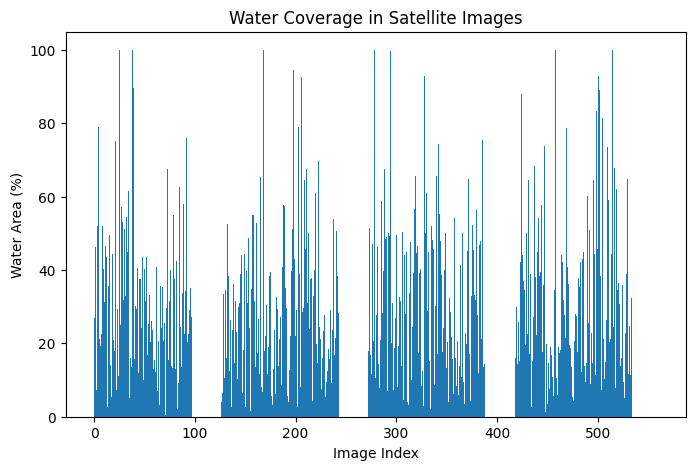

In [18]:
#Bar Graph
plt.figure(figsize=(8,5))
plt.bar(range(len(percentages)), percentages)

plt.title("Water Coverage in Satellite Images")
plt.xlabel("Image Index")
plt.ylabel("Water Area (%)")

plt.show()

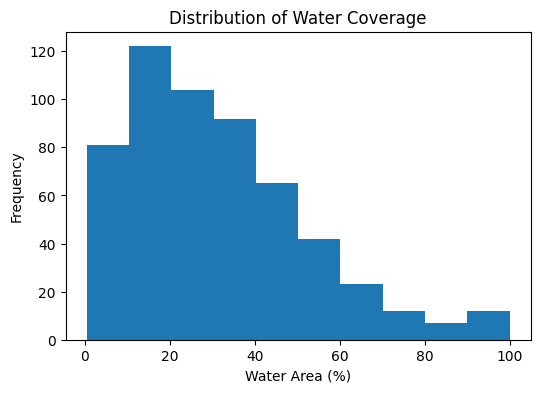

In [19]:
#Histogram
plt.figure(figsize=(6,4))
plt.hist(percentages, bins=10)

plt.title("Distribution of Water Coverage")
plt.xlabel("Water Area (%)")
plt.ylabel("Frequency")

plt.show()

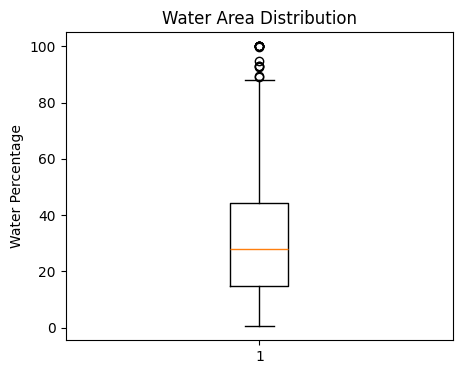

In [20]:
#Box Plot
plt.figure(figsize=(5,4))
plt.boxplot(percentages)

plt.title("Water Area Distribution")
plt.ylabel("Water Percentage")

plt.show()

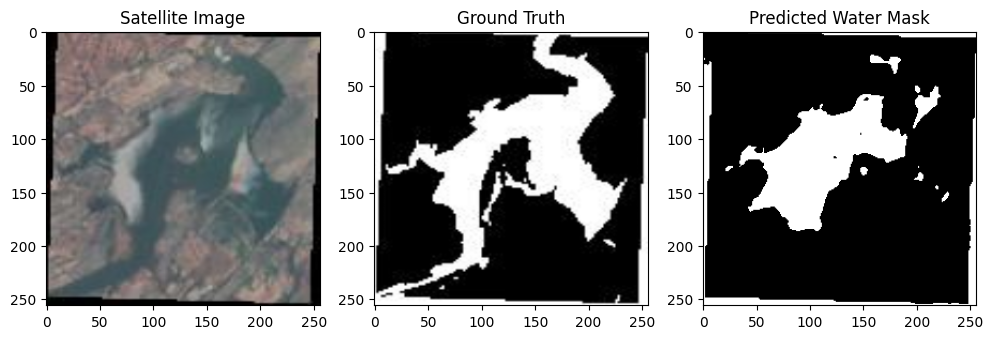

In [23]:
#Prediction Visualization
idx = 5

# Get a batch of validation images and masks from the generator
X_val, y_val = val_gen[0] # Assuming you want to visualize from the first batch

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(X_val[idx])
plt.title("Satellite Image")

plt.subplot(1,3,2)
plt.imshow(y_val[idx].squeeze(), cmap='gray')
plt.title("Ground Truth")

plt.subplot(1,3,3)
plt.imshow(pred_masks[idx].squeeze(), cmap='gray')
plt.title("Predicted Water Mask")

plt.show()

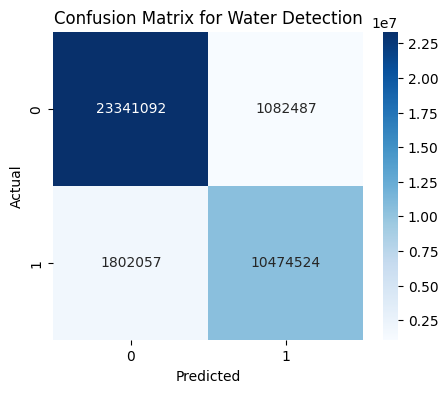

In [27]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np # Ensure numpy is imported

# Collect all true masks from the validation generator
all_y_true = []
for i in range(len(val_gen)):
    _, batch_y = val_gen[i]
    all_y_true.append(batch_y)

y_true = np.concatenate(all_y_true, axis=0).flatten()
y_true = (y_true > 0.5).astype(np.uint8) # Binarize y_true to match y_pred
y_pred = pred_masks.flatten()

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix for Water Detection")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

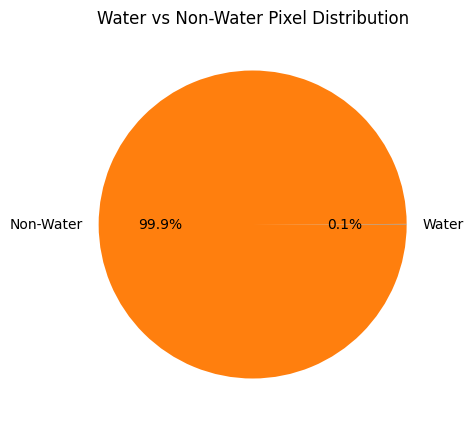

In [28]:
#Water vs Non-Water Pixel Distributionwater_pixels = np.sum(pred_masks)
non_water_pixels = pred_masks.size - water_pixels

labels = ['Water', 'Non-Water']
values = [water_pixels, non_water_pixels]

plt.figure(figsize=(5,5))
plt.pie(values, labels=labels, autopct='%1.1f%%')

plt.title("Water vs Non-Water Pixel Distribution")

plt.show()

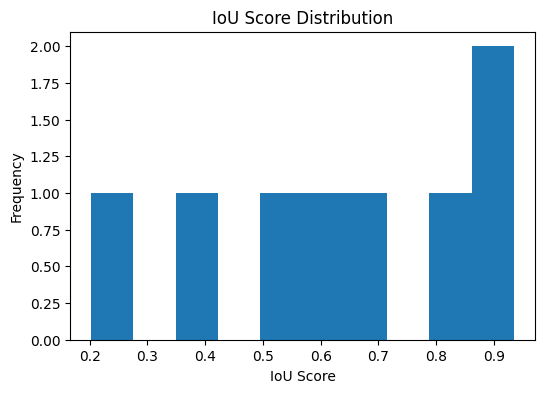

In [29]:
#IoU Score Distribution
iou_scores = []

for i in range(len(y_val)):

    intersection = np.logical_and(y_val[i], pred_masks[i]).sum()
    union = np.logical_or(y_val[i], pred_masks[i]).sum()

    if union == 0:
        iou = 0
    else:
        iou = intersection / union

    iou_scores.append(iou)

plt.figure(figsize=(6,4))
plt.hist(iou_scores, bins=10)

plt.title("IoU Score Distribution")
plt.xlabel("IoU Score")
plt.ylabel("Frequency")

plt.show()

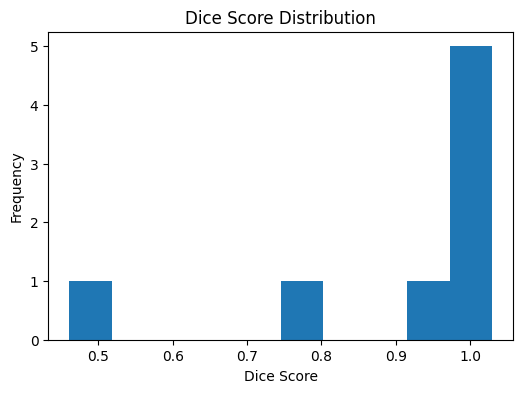

In [30]:
#Dice Score Distribution
dice_scores = []

for i in range(len(y_val)):

    intersection = np.logical_and(y_val[i], pred_masks[i]).sum()

    dice = (2 * intersection) / (np.sum(y_val[i]) + np.sum(pred_masks[i]) + 1e-6)

    dice_scores.append(dice)

plt.figure(figsize=(6,4))
plt.hist(dice_scores, bins=10)

plt.title("Dice Score Distribution")
plt.xlabel("Dice Score")
plt.ylabel("Frequency")

plt.show()

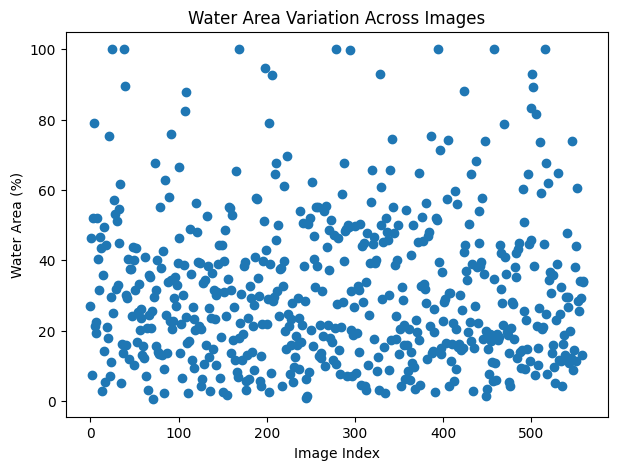

In [31]:
#Scatter Plot: Water Area vs Image Index
plt.figure(figsize=(7,5))

plt.scatter(range(len(percentages)), percentages)

plt.title("Water Area Variation Across Images")
plt.xlabel("Image Index")
plt.ylabel("Water Area (%)")

plt.show()

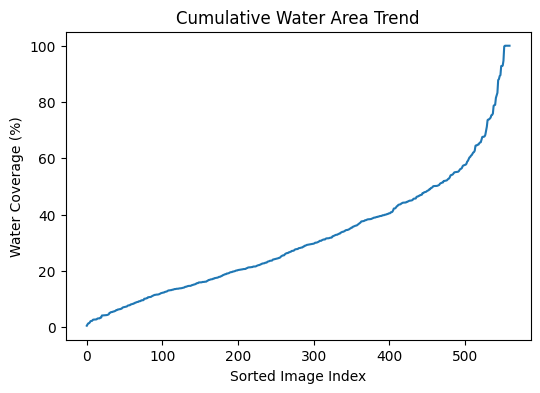

In [32]:
#Cumulative Water Area Curve
sorted_water = np.sort(percentages)

plt.figure(figsize=(6,4))
plt.plot(sorted_water)

plt.title("Cumulative Water Area Trend")
plt.xlabel("Sorted Image Index")
plt.ylabel("Water Coverage (%)")

plt.show()

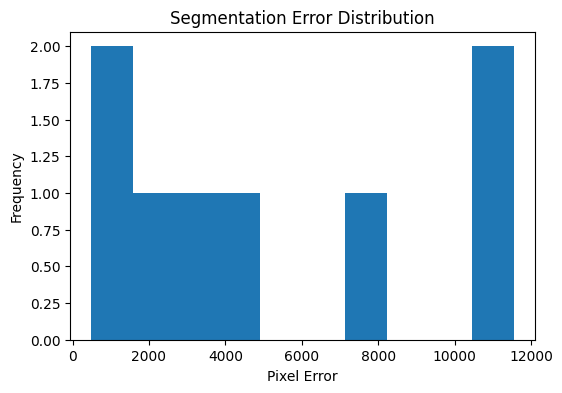

In [33]:
#Error Distribution Graph
errors = []

for i in range(len(y_val)):
    error = np.sum(np.abs(y_val[i] - pred_masks[i]))
    errors.append(error)

plt.figure(figsize=(6,4))
plt.hist(errors, bins=10)

plt.title("Segmentation Error Distribution")
plt.xlabel("Pixel Error")
plt.ylabel("Frequency")

plt.show()

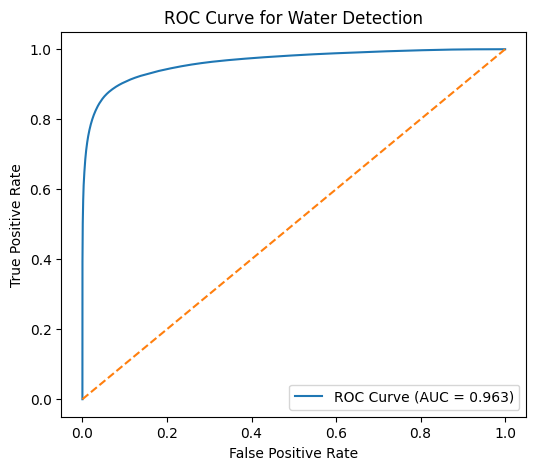

In [36]:
#ROC Curve (Receiver Operating Characteristic)
from sklearn.metrics import roc_curve, auc

# Collect all true masks from the validation generator
all_y_true_roc = []
for i in range(len(val_gen)):
    _, batch_y_roc = val_gen[i]
    all_y_true_roc.append(batch_y_roc)

y_true = np.concatenate(all_y_true_roc, axis=0).flatten()
y_pred_prob = predictions.flatten()

# Binarize y_true
y_true_binary = (y_true > 0.5).astype(np.uint8)

# ROC calculation
fpr, tpr, thresholds = roc_curve(y_true_binary, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label='ROC Curve (AUC = %0.3f)' % roc_auc)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Water Detection")
plt.legend()

plt.show()

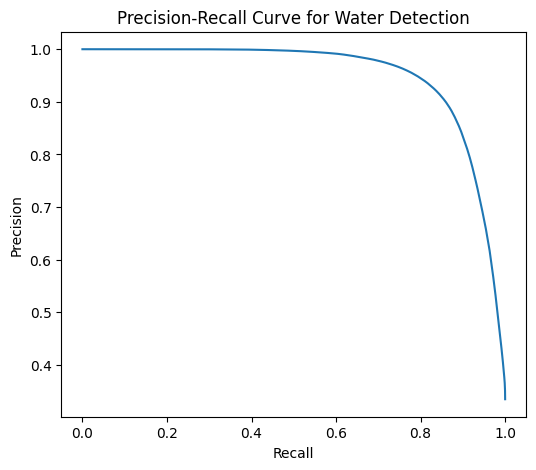

In [39]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_true_binary, y_pred_prob)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Water Detection")

plt.show()

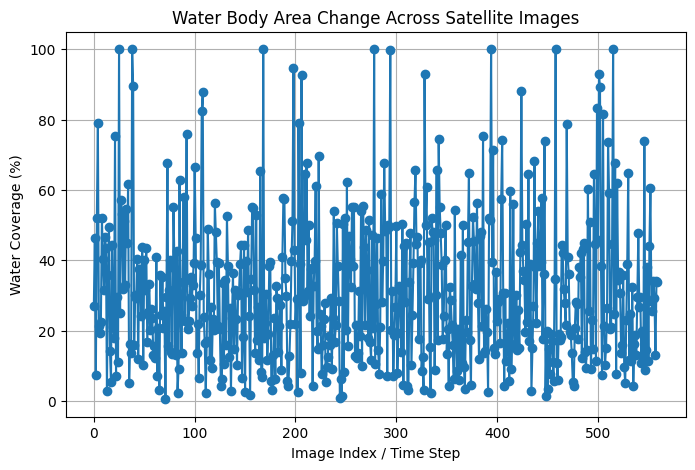

In [40]:
#Water Area Change Trend Graph (Environmental Analysis)
plt.figure(figsize=(8,5))

plt.plot(percentages, marker='o')

plt.title("Water Body Area Change Across Satellite Images")
plt.xlabel("Image Index / Time Step")
plt.ylabel("Water Coverage (%)")

plt.grid(True)

plt.show()